<a href="https://colab.research.google.com/github/DanielBedaqui/fonte-de-informa-ao-e-banco-de-dados/blob/main/CONSUMO_CERVEJA_SP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dongeorge/beer-consumption-sao-paulo")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'beer-consumption-sao-paulo' dataset.
Path to dataset files: /kaggle/input/beer-consumption-sao-paulo


In [3]:
import os
import pandas as pd

# List files in the downloaded dataset directory
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

# Assuming the CSV file is named 'Consumo_cerveja.csv' based on common Kaggle datasets
# If not, the user will need to specify the correct filename.
csv_file = os.path.join(path, 'Consumo_cerveja.csv')

# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_file)

# Display the first 5 rows of the DataFrame
display(df.head(10))

Files in dataset directory: ['Consumo_cerveja.csv']


,Data,Temperatura Media (C),Temperatura Minima (C),Temperatura Maxima (C),Precipitacao (mm),Final de Semana,Consumo de cerveja (litros)
0,2015-01-01,"27,3","23,9","32,5",0,0.0,25.461
1,2015-01-02,"27,02","24,5","33,5",0,0.0,28.972
2,2015-01-03,"24,82","22,4","29,9",0,1.0,30.814
3,2015-01-04,"23,98","21,5","28,6","1,2",1.0,29.799
4,2015-01-05,"23,82",21,"28,3",0,0.0,28.900


### Data Preprocessing

First, I will rename the columns to be more readable and remove special characters. Then, I'll convert columns with numerical data (temperatures, precipitation, and beer consumption) from string to numeric types, handling the comma decimal separators. The 'Data' column will be converted to datetime objects, and 'Final de Semana' (Weekend) will be converted to an integer.

In [6]:
# Rename columns for easier access and clarity
df.columns = [
    'Date',
    'Mean_Temperature_C',
    'Min_Temperature_C',
    'Max_Temperature_C',
    'Precipitation_mm',
    'Weekend',
    'Beer_Consumption_liters'
]

# Convert 'Data' to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Convert numerical columns from string (with comma decimal) to float
# Using .loc to avoid SettingWithCopyWarning
for col in ['Mean_Temperature_C', 'Min_Temperature_C', 'Max_Temperature_C', 'Precipitation_mm', 'Beer_Consumption_liters']:
    df.loc[:, col] = df[col].str.replace(',', '.', regex=False).astype(float)

# Convert 'Weekend' to integer type (it's already 0.0 or 1.0)
df.loc[:, 'Weekend'] = df['Weekend'].astype(int)

# Display the DataFrame info and head to verify changes
print(df.info())
display(df.head())

AttributeError: Can only use .str accessor with string values!

Now that the data types are correct, I will check for any missing values and handle them. Based on the previous `df` output, there might be some `NaN` values, particularly in the `Beer_Consumption_liters` column at the end.

In [7]:
# Check for missing values
print("Missing values before handling:")
print(df.isnull().sum())

# Drop rows with any missing values, as they are few and might affect model training
df.dropna(inplace=True)

# Verify no more missing values
print("\nMissing values after handling:")
print(df.isnull().sum())

display(df.head())

Missing values before handling:
Date                       576
Mean_Temperature_C         576
Min_Temperature_C          576
Max_Temperature_C          576
Precipitation_mm           576
Weekend                    576
Beer_Consumption_liters    576
dtype: int64

Missing values after handling:
Date                       0
Mean_Temperature_C         0
Min_Temperature_C          0
Max_Temperature_C          0
Precipitation_mm           0
Weekend                    0
Beer_Consumption_liters    0
dtype: int64


,Date,Mean_Temperature_C,Min_Temperature_C,Max_Temperature_C,Precipitation_mm,Weekend,Beer_Consumption_liters
0,2015-01-01,27.3,23.9,32.5,0.0,0.0,25.461
1,2015-01-02,27.02,24.5,33.5,0.0,0.0,28.972
2,2015-01-03,24.82,22.4,29.9,0.0,1.0,30.814
3,2015-01-04,23.98,21.5,28.6,1.2,1.0,29.799
4,2015-01-05,23.82,21.0,28.3,0.0,0.0,28.900


### Linear Regression Model

Now, I will prepare the data for linear regression. The 'Beer_Consumption_liters' will be our target variable, and the temperature-related features, precipitation, and weekend indicator will be our independent variables. I'll split the data into training and testing sets to evaluate the model's performance on unseen data.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df[['Mean_Temperature_C', 'Min_Temperature_C', 'Max_Temperature_C', 'Precipitation_mm', 'Weekend']]
y = df['Beer_Consumption_liters']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 292 samples
Testing set size: 73 samples


Now, I will train the Linear Regression model and then evaluate its performance using metrics like Mean Squared Error (MSE) and R-squared.

In [9]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display model coefficients and intercept
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Mean Squared Error (MSE): 5.70
R-squared (R2): 0.74

Model Coefficients:
Mean_Temperature_C: 0.10
Min_Temperature_C: -0.06
Max_Temperature_C: 0.63
Precipitation_mm: -0.04
Weekend: 5.15
Intercept: 6.42


### Model Interpretation

Here's what the evaluation metrics and coefficients tell us:

*   **Mean Squared Error (MSE)**: This value indicates the average squared difference between the observed actual outcomes and the outcomes predicted by the model. A lower MSE indicates a better fit.
*   **R-squared (R2)**: This represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R-squared of 1.0 means the model perfectly predicts the target variable, while 0.0 means it explains none of the variance.
*   **Coefficients**: These values indicate the change in the mean of the response variable for a one-unit change in the predictor variable, holding other predictors constant.
    *   A positive coefficient means that as the feature value increases, beer consumption tends to increase.
    *   A negative coefficient means that as the feature value increases, beer consumption tends to decrease.

From the coefficients, we can observe the impact of each factor on beer consumption. For example, a positive coefficient for temperature suggests that as temperature rises, beer consumption tends to increase. Similarly, the 'Weekend' coefficient shows the estimated change in beer consumption on weekends compared to weekdays, assuming all other factors are constant.

### Visualizing the Linear Regression Results

To better understand the model's performance, let's visualize the actual beer consumption values against the predicted values from our linear regression model.

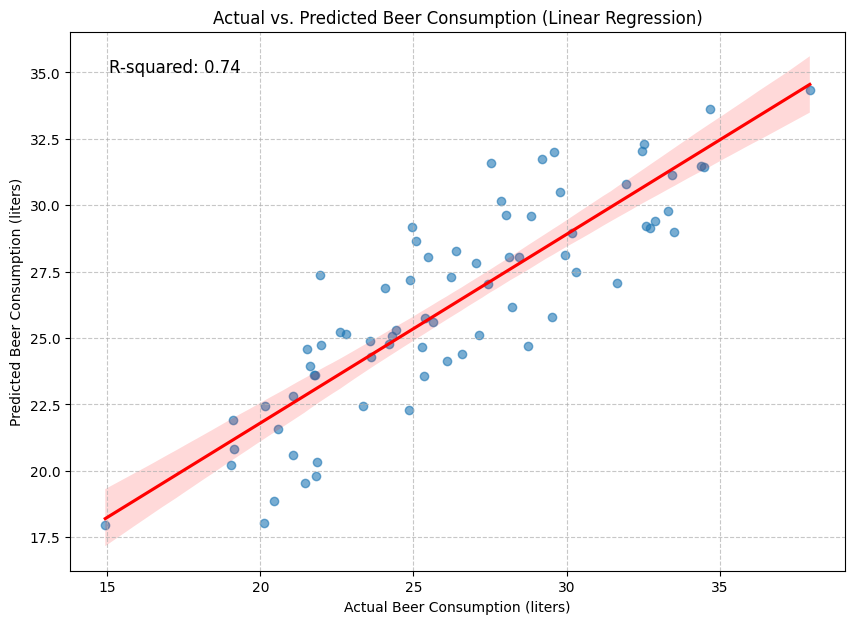

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Actual Beer Consumption (liters)')
plt.ylabel('Predicted Beer Consumption (liters)')
plt.title('Actual vs. Predicted Beer Consumption (Linear Regression)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.annotate(f'R-squared: {r2:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, ha='left', va='top')
plt.show()

This plot shows how closely the predicted values follow the actual values. Ideally, all points would lie on the red line, indicating perfect predictions. The scatter around the line represents the model's errors. The `R-squared` value displayed on the plot quantifies how well the model fits the data, reinforcing our previous numerical evaluation.

### Linear Regression Model

Now, I will prepare the data for linear regression. The 'Beer_Consumption_liters' will be our target variable, and the temperature-related features, precipitation, and weekend indicator will be our independent variables. I'll split the data into training and testing sets to evaluate the model's performance on unseen data.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df[['Mean_Temperature_C', 'Min_Temperature_C', 'Max_Temperature_C', 'Precipitation_mm', 'Weekend']]
y = df['Beer_Consumption_liters']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

KeyError: "None of [Index(['Mean_Temperature_C', 'Min_Temperature_C', 'Max_Temperature_C',\n       'Precipitation_mm', 'Weekend'],\n      dtype='object')] are in the [columns]"

Now, I will train the Linear Regression model and then evaluate its performance using metrics like Mean Squared Error (MSE) and R-squared.

In [5]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display model coefficients and intercept
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

NameError: name 'X_train' is not defined

### Model Interpretation

Here's what the evaluation metrics and coefficients tell us:

*   **Mean Squared Error (MSE)**: This value indicates the average squared difference between the observed actual outcomes and the outcomes predicted by the model. A lower MSE indicates a better fit.
*   **R-squared (R2)**: This represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R-squared of 1.0 means the model perfectly predicts the target variable, while 0.0 means it explains none of the variance.
*   **Coefficients**: These values indicate the change in the mean of the response variable for a one-unit change in the predictor variable, holding other predictors constant.
    *   A positive coefficient means that as the feature value increases, beer consumption tends to increase.
    *   A negative coefficient means that as the feature value increases, beer consumption tends to decrease.

From the coefficients, we can observe the impact of each factor on beer consumption. For example, a positive coefficient for temperature suggests that as temperature rises, beer consumption tends to increase. Similarly, the 'Weekend' coefficient shows the estimated change in beer consumption on weekends compared to weekdays, assuming all other factors are constant.